In [2]:
from sympy import symbols, Rational
from sympy.utilities.codegen import codegen
from sympy.codegen.rewriting import optimize, optims_c99
from sympy.simplify.cse_main import cse
import sympy as sp
from sympy import S
from sympy.printing.c import C99CodePrinter, Assignment
from sympy import init_printing
from codegen.codegen_utils import * 
init_printing()
printer = MyPrinter() 


In [3]:
def der_scalar(s,name):
    _d = sp.Matrix([0]*3)
    for idir in range(3):
        _d[idir] = sp.symbols(f"d{name}_dx[{idir}]", real=True)
    return _d 
def der_vec(vec,name):
    out = [] 
    n = vec.shape[0]
    for idir in range(3):
        _out = sp.Matrix([0]*n)
        for i in range(n):
            _out[i] = sp.symbols(f"d{name}_dx[{ i + n * idir}]")
        out.append(_out)
    return out
def der_symm_tens(mat,name):
    rows, cols = mat.shape
    if rows != cols: raise ValueError("Non-square tensor cannot be symmetric")
    n = rows 
    ncomps = n * (n+1)//2 
    out = [] 
    for idir in range(3):
        _out = sp.MutableDenseMatrix(n, n, [0]* (n*n))
        icomp = 0 
        for i in range(n):
            for j in range(i,n):
                # order idir, i, j
                _out[i,j] = _out[j,i] = sp.symbols(f"d{name}_dx[{icomp + ncomps * idir}]")
                icomp += 1
        out.append(_out)
    return out

Basic 3+1 stuff:

normal to hypersurfaces
$$
n^\nu = \begin{pmatrix}
1/\alpha & -\beta^x/\alpha & -\beta^y/\alpha & -\beta^z/\alpha 
\end{pmatrix}
$$
and
$$
n_\nu = \begin{pmatrix}
-\alpha & 0 & 0 & 0 
\end{pmatrix}
$$



4-metric 
$$
g_{\mu\nu} = \begin{pmatrix} 
-\alpha^2 + \beta^i \beta_i & \beta_x & \beta_y & \beta_z \\
\beta_x & \gamma_{xx} & \gamma_{xy} & \gamma_{xz} \\ 
\beta_y & \gamma_{xy} & \gamma_{yy} & \gamma_{yz} \\ 
\beta_z & \gamma_{xz} & \gamma_{yz} & \gamma_{zz} \\ 
\end{pmatrix}
$$
inverse
$$
g^{\mu\nu} = \begin{pmatrix} 
-1/\alpha^2 & \beta^x/\alpha^2 & \beta^y/\alpha^2 & \beta^z/\alpha^2 \\
\beta^x/\alpha^2 & \gamma^{xx} - \beta^x \beta^x/\alpha^2 & \gamma^{xy} - \beta^x \beta^y/\alpha^2 & \gamma^{xz} - \beta^x \beta^z/\alpha^2 \\ 
\beta^y/\alpha^2 & \gamma^{xy} - \beta^x \beta^y/\alpha^2 & \gamma^{yy} - \beta^y \beta^y/\alpha^2 & \gamma^{yz} - \beta^y \beta^z/\alpha^2 \\ 
\beta^z/\alpha^2 & \gamma^{xz} - \beta^x \beta^z/\alpha^2 & \gamma^{yz} - \beta^y \beta^z/\alpha^2 & \gamma^{zz} - \beta^z \beta^z/\alpha^2 \\ 
\end{pmatrix}
$$


In [4]:
# Metric 
gxx,gxy,gxz,gyy,gyz,gzz = symbols("gdd[0] gdd[1] gdd[2] gdd[3] gdd[4] gdd[5]", real=True) 
gdd = sp.Matrix([
    [gxx,gxy,gxz],
    [gxy,gyy,gyz],
    [gxz,gyz,gzz]
])
gXX,gXY,gXZ,gYY,gYZ,gZZ = symbols("guu[0] guu[1] guu[2] guu[3] guu[4] guu[5]", real=True) 
guu = sp.Matrix([
    [gXX,gXY,gXZ],
    [gXY,gYY,gYZ],
    [gXZ,gYZ,gZZ]
])
betaX, betaY, betaZ = symbols("betau[0] betau[1] betau[2]", real=True) 
betau = sp.Matrix([betaX,betaY,betaZ])
Kxx,Kxy,Kxz,Kyy,Kyz,Kzz = symbols("Kdd[0] Kdd[1] Kdd[2] Kdd[3] Kdd[4] Kdd[5]", real=True) 
Kdd = sp.Matrix([
    [Kxx,Kxy,Kxz],
    [Kxy,Kyy,Kyz],
    [Kxz,Kyz,Kzz]
])


betad = gdd * betau

alpha = symbols("alp", real=True, nonnegative=True)

nU = sp.Matrix([1/alpha, -betau[0]/alpha, -betau[1]/alpha, -betau[2]/alpha])
nD = sp.Matrix([-alpha,0,0,0])

g4dd = sp.Matrix(
    [
        [-alpha**2 + betad.dot(betau), betad[0], betad[1], betad[2]],
        [betad[0], gdd[0,0], gdd[0,1], gdd[0,2]],
        [betad[1], gdd[1,0], gdd[1,1], gdd[1,2]],
        [betad[2], gdd[2,0], gdd[2,1], gdd[2,2]]
    ]
)

g4uu = sp.Matrix(4,4,[0]*4*4)

g4uu[0,0] = -1/alpha**2
for mu in range(3):
    g4uu[0,mu+1] = g4uu[mu+1,0] = betau[mu]/alpha**2
    for nu in range(3):
        g4uu[mu+1,nu+1] = guu[mu,nu] - betau[mu] * betau[nu] / alpha**2 



In [5]:
# Hydro primitives 
rho, P, eps, T, s = symbols("rho press eps T s", real=True)
zX, zY, zZ, W     = symbols("zvec[0] zvec[1] zvec[2] W", real=True)
BX, BY, BZ        = symbols("Bvec[0] Bvec[1] Bvec[2]", real=True)

zvecu = sp.Matrix([zX,zY,zZ])
Bvecu = sp.Matrix([BX,BY,BZ])

Bvecd = gdd * Bvecu 
zvecd = gdd * zvecu 

B2 = Bvecu.dot(Bvecd)

Basic definitions: 
Specific enthalpy
$$
h=1+\epsilon+P/\rho
$$
Lorentz factor
$$
W^2 = 1+z^i z_i
$$
Eulerian velocity
$$
v^i = \frac{z^i}{W} = \frac{u^i}{\alpha u^t} + \frac{\beta^i}{\alpha}
$$
$$
u^t = \frac{W}{\alpha}
$$
Transport velocity
$$
\tilde{v}^i = \frac{u^i}{u^t} = \alpha v^i - \beta^i
$$

In [6]:
# Basic derived qties 
h = 1 + eps + P/rho 
W_expl = sp.sqrt(1+zvecu.dot(zvecd))
velu = zvecu / W 
veld = gdd * velu 
v2 = velu.dot(veld)

u0 = W / alpha 
u3u =  (alpha*velu-betau) * u0 
u4u = sp.Matrix([u0,*u3u])
u4d = g4dd * u4u 
u3d = sp.Matrix([u4d[1],u4d[2],u4d[3]])

vtildeu = alpha*velu-betau

Comoving magnetic field:
$$
b^t = \frac{B^i u_i}{\alpha} = u^t ( B^i v_i ) = u^t (\frac{B^i u_i}{W}) \, ,
$$
$$
b^i = \frac{B^i + \alpha b^t u^i}{W}
$$
Square norm:
$$
b^2 = b^\alpha b_\alpha = \frac{B^i B_i + \alpha^2 (b^t)^2}{W^2}
$$


In [7]:
# comoving B 
Bdotv = Bvecu.dot(veld)
bt_expl = Bvecu.dot(veld) * u0 
bi_expl = (Bvecu + alpha * bt_expl*u3u)/W
b2_expl = (B2 + alpha**2 * bt_expl**2)/W**2
b4u_expl = sp.Matrix([bt_expl,*bi_expl])

bt, bX, bY, bZ, b2 = sp.symbols("smallbu[0] smallbu[1] smallbu[2] smallbu[3] b2")
vtX_s, vtY_s, vtZ_s = sp.symbols("vtildeu[0] vtildeu[1] vtildeu[2]")

b4u = sp.Matrix([bt,bX,bY,bZ])
b4d = g4dd * b4u 
b3u = sp.Matrix([bX,bY,bZ])
b3d = sp.Matrix([b4d[1],b4d[2],b4d[3]])

Ptot = P + b2 / 2 


sub_btilde_vtilde = {
    vtildeu[0]: vtX_s,
    vtildeu[1]: vtY_s,
    vtildeu[2]: vtZ_s,
}

In [8]:
test = b4u_expl.T * g4dd * b4u_expl 
print(sp.simplify(test[0].subs({W:W_expl})-b2_expl.subs({W: W_expl})))

0


In [40]:
scalar = ("double", None)
vec = ("double", [3])
fvec = ("double", [4])

ABI=  {
    # Metric 
    "alp": scalar,
    "betau": vec,
    "gdd": ("double",[6]),
    "guu": ("double",[6]),
    "Kdd": ("double",[6]),
    # Metric derivatives 
    "dalpha_dx": ("double",[3]),
    "dgdd_dx": ("double",[6*3]),
    "dbetau_dx": ("double",[3*3]),
    # Hydro 
    "rho": scalar,
    "press": scalar,
    "eps": scalar,
    "Bvec": vec,
    "zvec": vec,
    "cs2": scalar,
    "s": scalar,
    "W": scalar, 
    'b2': scalar
}


ABI["smallbu"] = fvec
ABI["vtildeu"] = vec

Definition of stress-energy tensor:
$$
T^{\mu\nu} = \left( \rho\, h + b^2 \right) u^\mu u^\nu + \left( P + \frac{b^2}{2} \right) g^{\mu\nu} - b^\mu b^\nu
$$
And spatial projection
$$
W^{ij} = \gamma^i_\mu \gamma^j_\nu \, T^{\mu\nu} = \left( T^{00} \beta^i \beta^j + 2 T^{0i} \beta^j + T^{ij} \right)
$$

In [10]:
# Construct Tupmunu 
Tupmunu = sp.zeros(4,4)
TupmunuEM = sp.zeros(4,4)

for mu in range(4):
    for nu in range(mu,4):
        Tupmunu[mu,nu] = Tupmunu[nu,mu] = (rho*h + b2_expl) * u4u[mu] * u4u[nu] + (P + b2_expl/2) * g4uu[mu,nu] - b4u_expl[mu] * b4u_expl[nu]
        TupmunuEM[mu,nu] = TupmunuEM[nu,mu] = b2_expl * u4u[mu] * u4u[nu] + b2_expl/2 * g4uu[mu,nu] - b4u_expl[mu] * b4u_expl[nu]

Wij = sp.Matrix(3,3,[0]*9)
for i in range(3):
    for j in range(i,3):
        Wij[i,j] = Wij[j,i] = (Tupmunu[0,0] * betau[i] * betau[j] + 2 * Tupmunu[0,i+1] * betau[j] + Tupmunu[i+1,j+1])

WIj = Wij * gdd 

E_em = sp.simplify(nD.T * TupmunuEM * nD)

In [ ]:
test = b4u_expl * b4u_expl.T
test = nD.T*test*nD
sp.simplify(test[0] - alpha**2*bt_expl**2)

In [22]:
test = b2_expl * u4u * u4u.T 
test = nD.T*test*nD
rest = B2 + Bdotv**2*W**2
sp.simplify(test[0] - rest)

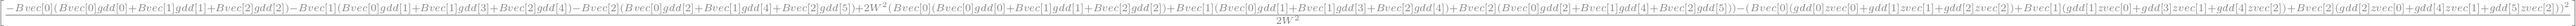

In [ ]:
E_em

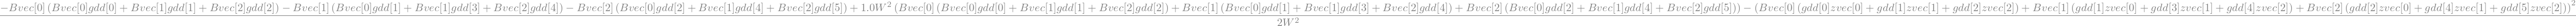

In [23]:

test = 0.5 * B2 #0.5 * alpha * u0 * b2_expl
sp.simplify(E_em[0]-test)

Conserved variables (undensitized)
Rest-mass density
$$
D = W \, \rho 
$$
Energy density 
$$
\tau = n_\mu n_\nu T^{\mu\nu} - D = \alpha^2 T^{00} - D = W^2 \left( \rho h + b^2 \right) - \left( P + \frac{b^2}{2} \right) - \alpha^2 (b^t)^2 - D 
$$
Momentum density 
$$
S_i = W \left( \rho h + b^2 \right) u_i - \alpha b^t b_i
$$

In [42]:
# conserved 
D =  W * rho 
tau = ( W**2*(rho*h+b2) - Ptot - alpha**2 *bt**2 - D )
Std = alpha * (( rho*h + b2 ) * u0 * u3d - bt * b3d)
stilde = s * D 

# Test 
print(sp.simplify(tau.subs({b2:b2_expl,b4u[0]:b4u_expl[0]})-alpha**2*Tupmunu[0,0]+D))

0


Wavespeeds:
Alfvén speed
$$
v^2_{\rm A} = \frac{b^2}{b^2 + \rho h}
$$
Speed 
$$
v^2_0 = v^2_{\rm A} + c_s^2 ( 1 - v_{\rm A}^2 ) 
$$
Then we solve the quadratic
$$
a c_{\pm}^2 + b c_{\pm} + c = 0 
$$
With 
$$
a = (u^t)^2 ( 1 - v_0^2 ) + \frac{v_0^2}{\alpha^2}
$$
$$
b = 2 \left( \frac{\beta^d}{\alpha^2} v_0^2 - (u^t)^2 \tilde{v}^d  (1-v_0^2) \right)
$$
and
$$
c = (u^t)^2  (\tilde{v}^d)^2 (1-v_0^2) - v_0^2 \left[ \gamma^{dd} - \left( \frac{\beta^d}{\alpha} \right)^2 \right]
$$

In [43]:
# Wavespeeds 
cs2, betauDIR, vtildeuDIR, guuDIRDIR, b3uDIR = symbols("cs2 betau[idir] vtildeu[idir] guuDD smallbu[1+idir]", real=True)
ABI["guuDD"] = scalar 


va2 = (b2 / (b2+rho*h)).subs(sub_btilde_vtilde)
v02 = va2 + cs2 * ( 1 - va2 )


A = u0**2 * ( 1-v02 ) + v02 / alpha**2 
B = 2 * ( betauDIR/alpha**2 * v02 - u0**2 * vtildeuDIR * (1-v02) )
C = u0**2 * vtildeuDIR**2 * ( 1-v02 ) - v02 * (guuDIRDIR-betauDIR**2/alpha**2)
det = sp.sqrt(sp.Max(0, B**2-4*A*C))
c1 =  (det-B)/(2*A)
c2 = -(det+B)/(2*A)

cm = sp.Min(c1,c2)
cp = sp.Max(c1,c2)

Fluxes:
$$
F^i_D = D \tilde{v}^i
$$
$$
F^i_\tau = \alpha^2 T^{0i} - F^i_D = W^2 \left( \rho h + b^2 \right) \tilde{v}^i + \left( P + \frac{b^2}{2} \right) \beta^i - \alpha^2 b^t b^i - D \tilde{v}^i
$$
And 
$$
F^i_{S_j} = \alpha {T^i}_j =  \alpha \left\{ \left( \rho h + b^2 \right) u^i u_j + \left( P + \frac{b^2}{2} \right) \delta^i_j - b^i b_j \right\}
$$

In [44]:
idir = symbols("idir", integer=True, nonnegative=True)
ABI["idir"] = ("int", None)
# fluxes 
fD = (D * vtildeuDIR).subs(sub_btilde_vtilde)
fSd = sp.Matrix([0]*3)
ftau =  (W**2 * (rho*h + b2) * vtildeuDIR + Ptot * betauDIR- alpha**2 * bt * b3uDIR - fD).subs(sub_btilde_vtilde)


for j in range(3):
    fSd[j] = (alpha * ( ( rho * h + b2 ) * u0 * vtildeuDIR * u3d[j] + Ptot * sp.Piecewise((1, sp.Eq(idir,j)), (0, True)) - b3uDIR * b3d[j] )).subs(sub_btilde_vtilde)

fstilde = stilde * vtildeuDIR 
vtilde = vtildeu 

Source terms:
$$
S_\tau = \alpha \left[ W^{ij} K_{ij} - \left( T^{00} \, \beta^i + T^{0i} \right) \partial_i \alpha \right]
$$
$$
S_{S_j} = \frac{1}{2} \alpha T^{\alpha\beta} \partial_j g_{\alpha\beta}
$$
Metric derivatives:
$$
\partial_j g_{tt} = \partial_j \left( -\alpha^2 + \beta^i \beta_i \right) = - 2 \alpha \partial_j \alpha + \partial_j ( \gamma_{lm} \, \beta^l \beta^m) = - 2 \alpha \partial_j \alpha + \beta^l \beta^m \partial_j \gamma_{lm} + 2 \gamma_{lm} \beta^l \partial_j \beta^m
$$
We can rewrite 
$$
\partial_j \beta_i = \partial_j ( \gamma_{ki} \beta^k ) = \gamma_{ki} \partial_j \beta^k + \beta^k \partial_j \gamma_{ki}
$$
So that 
$$
\partial_j g_{ti} = \partial_j \beta_i = \gamma_{ki} \partial_j \beta^k + \beta^k \partial_j \gamma_{ki}
$$ 
And finally 
$$
\partial_j g_{ij} = \partial_j \gamma_{ij}
$$

In [45]:
# metric derivatives 
dgdd_dx = der_symm_tens(gdd,"gdd")
dbetau_dx = der_vec(betau,"betau")
dalpha_dx = der_scalar("alp",alpha)

# four metric derivative 
dg4dd_dx = [] 
for id in range(3):
    _dgdd_dxi = sp.zeros(4,4)
    # g_tt see above
    _dgdd_dxi[0,0] = - S(2) * alpha * dalpha_dx[id] 
    for l in range(3):
        for m in range(3):
            _dgdd_dxi[0,0] += betau[l] * betau[m] * dgdd_dx[id][l,m] + S(2) * gdd[l,m] * betau[l] * dbetau_dx[id][m]
    # g_ti
    for i in range(3):
        for l in range(3):
            _dgdd_dxi[0,i+1] +=  gdd[l,i] * dbetau_dx[id][l] + betau[l] * dgdd_dx[id][l,i]
        _dgdd_dxi[i+1,0] = _dgdd_dxi[0,i+1]
    # g_ij
    for i in range(3):
        for j in range(i,3):
            _dgdd_dxi[i+1,j+1] = dgdd_dx[id][i,j]
            _dgdd_dxi[j+1,i+1]= _dgdd_dxi[i+1,j+1]
    
    dg4dd_dx.append(_dgdd_dxi)

In [13]:
# Fold in the sources
S_source = sp.MutableDenseMatrix([0]*3)
tau_source = 0 
for i in range(3):
    tau_source -= alpha * (Tupmunu[0,0] * betau[i] + Tupmunu[0,i+1]) * dalpha_dx[i]
    for j in range(3):
        tau_source += alpha * Wij[i,j] * Kdd[i,j]

for i in range(3):
    for j in range(4):
        for k in range(4):
            S_source[i] += Rational(1,2) * alpha * dg4dd_dx[i][j,k] * Tupmunu[j,k] 

sources = sp.Matrix([tau_source, S_source[0], S_source[1], S_source[2]])

In [14]:
flist = []

# First: get W from zvec 
out_list = ["W"]
out_abi = {"W": scalar}
flist.append(make_function([W_expl],printer,"grmhd_get_W",ABI,out_list,out_abi))

# Next: smallb and smallb2 
out_list = ["smallb", "smallb2"]
out_abi = {"smallb": fvec, "smallb2": scalar}
flist.append(make_function([b4u_expl,b2_expl],printer,"grmhd_get_smallbu_smallb2",ABI,out_list,out_abi))

# Next: vtilde 
out_list = ["vtilde"]
out_abi = {"vtilde": vec}
flist.append(make_function([vtildeu],printer,"grmhd_get_vtildeu",ABI,out_list,out_abi))

# Next: wavespeeds 
out_list = ["cm", "cp"]
out_abi = {"cm": scalar, "cp": scalar}
flist.append(make_function([cm, cp],printer,"grmhd_get_cm_cp",ABI,out_list,out_abi,additional_inputs=[idir]))

# Next: fluxes 
out_list = ["dens", "tau", "stilde", "entstar", "fD", "ftau", "fstilde", "fentstar"]
out_abi = {"dens":scalar, "tau": scalar, "stilde": vec, "entstar": scalar,"fD": scalar, "ftau": scalar, "fstilde": vec, "fentstar": scalar}
flist.append(make_function([D, tau, Std, stilde, fD, ftau, fSd, fstilde],printer,"grmhd_get_fluxes",ABI,out_list,out_abi))


# Next source terms 
out_list = ["dtau", "dstilde"]
out_abi = {"dtau": scalar, "dstilde": vec}
flist.append(make_function([tau_source, S_source], printer, "grmhd_get_geom_sources", ABI, out_list, out_abi))


# Finally the conserved variables 
out_list = ["dens", "tau", "stilde", "entstar"]
out_abi = {"dens":scalar, "tau": scalar, "stilde": vec, "entstar": scalar}
flist.append(make_function([D, tau, Std, stilde], printer, "grmhd_get_conserved", ABI, out_list, out_abi))

# Finally the Tmunu
out_list = ["Tuu"]
out_abi = {"Tuu":("double",[10])}
flist.append(make_function([Tupmunu], printer, "grmhd_get_Tupmunu", ABI, out_list, out_abi))


printed_functions = '\n' + '\n'.join(flist)

In [15]:
file = '''
/****************************************************************************/
/*                     GRMHD helpers, SymPy generated                       */
/****************************************************************************/
#ifndef GRACE_GRMHD_SUBEXPR_HH
#define GRACE_GRMHD_SUBEXPR_HH

#include <Kokkos_Core.hpp>
''' + printed_functions + '''
#endif 
'''

with open("grmhd_subexpressions.hh","w") as ff:
    ff.write(file)

In [16]:
Tud = g4dd * Tupmunu 
TIj = Tud[1:,1:]
dFLUXES = (alpha * TIj[0,:] - fSd.subs({idir:0}).T)

In [17]:
expr = alpha * TIj[0,:]
expr2 = fSd

In [18]:
__expr = sp.lambdify([rho,*zvecu,*Bvecu,P,eps,gxx,gxy,gxz,gyy,gyz,gzz,gXX,gXY,gXZ,gYY,gYZ,gZZ,*betau,alpha],expr)
__expr2 = sp.lambdify([rho,*zvecu,*Bvecu,P,eps,gxx,gxy,gxz,gyy,gyz,gzz,gXX,gXY,gXZ,gYY,gYZ,gZZ,*betau,alpha],expr2)

In [19]:
prims = []
prims.append(1) # rho 
prims += [0,0,0] # z 
prims += [0,0,0] # 
prims.append(0.1) # press 
prims.append(0.1/1/(4/3-1)) # eps 

metric = [1,0,0,1,0,1]*2
metric += [0,0,0]
metric.append(1)
len(metric)

In [20]:
__expr(*prims,*metric)

array([[0.100000000000000, 0, 0]], dtype=object)